## HR Employee Attrition Prediction 

## Project Overview
This project uses machine learning to predict whether an employee is likely to resign based on HR-related factors such as salary, department,training hours,overtime ratio and performance rating.

## Objective 
The goal of this project is to analyze HR employee data and build a machine learning model that predicts whether an employee is likely to resign. 

In [61]:
import pandas as pd 
df = pd.read_csv("uncleaned_dataset.csv")
df.head()

,Employee_ID,Department,Gender,Age,Salary,Training_Hours,Performance_Rating,Overtime_Ratio,Status,Hire_Date
0,EMP1000,engineering,Female,26,76000.0,12,1.1,0.46,Active,2020-08-01
1,EMP1001,Product,Male,46,130000.0,24,2.8,0.04,Active,8/10/2024
2,EMP1002,Marketing,Non-binary,53,100000.0,12,0.4,0.06,Resigned,2020-03-01
3,EMP1003,Product,Female,39,130000.0,28,3.3,0.03,Active,2023-04-01
4,EMP1004,Product,Non-binary,60,150000.0,18,2.4,0.14,Resigned,2021-05-01


In [62]:
df.shape

(2000, 10)

In [63]:
df= df.dropna(subset=["Salary"])
df.shape

(1904, 10)

In [64]:
df["Salary"].isnull().sum()

np.int64(0)

In [65]:
df["Department"]= df["Department"].str.capitalize()
df.head()

,Employee_ID,Department,Gender,Age,Salary,Training_Hours,Performance_Rating,Overtime_Ratio,Status,Hire_Date
0,EMP1000,Engineering,Female,26,76000.0,12,1.1,0.46,Active,2020-08-01
1,EMP1001,Product,Male,46,130000.0,24,2.8,0.04,Active,8/10/2024
2,EMP1002,Marketing,Non-binary,53,100000.0,12,0.4,0.06,Resigned,2020-03-01
3,EMP1003,Product,Female,39,130000.0,28,3.3,0.03,Active,2023-04-01
4,EMP1004,Product,Non-binary,60,150000.0,18,2.4,0.14,Resigned,2021-05-01


In [66]:
df= df.dropna(subset=["Performance_Rating"])
df= df[(df["Performance_Rating"]>=0.0) & (df["Performance_Rating"]<=5.0)] 
df.head()

,Employee_ID,Department,Gender,Age,Salary,Training_Hours,Performance_Rating,Overtime_Ratio,Status,Hire_Date
0,EMP1000,Engineering,Female,26,76000.0,12,1.1,0.46,Active,2020-08-01
1,EMP1001,Product,Male,46,130000.0,24,2.8,0.04,Active,8/10/2024
2,EMP1002,Marketing,Non-binary,53,100000.0,12,0.4,0.06,Resigned,2020-03-01
3,EMP1003,Product,Female,39,130000.0,28,3.3,0.03,Active,2023-04-01
4,EMP1004,Product,Non-binary,60,150000.0,18,2.4,0.14,Resigned,2021-05-01


In [67]:
df["Hire_Date"]= df["Hire_Date"].astype(str).str.strip()
df["Hire_Date"]= pd.to_datetime(df["Hire_Date"],errors="coerce")
df["Hire_Date"]= df["Hire_Date"].dt.strftime("%Y-%m-%d")
df.head()

,Employee_ID,Department,Gender,Age,Salary,Training_Hours,Performance_Rating,Overtime_Ratio,Status,Hire_Date
0,EMP1000,Engineering,Female,26,76000.0,12,1.1,0.46,Active,2020-08-01
1,EMP1001,Product,Male,46,130000.0,24,2.8,0.04,Active,NaN
2,EMP1002,Marketing,Non-binary,53,100000.0,12,0.4,0.06,Resigned,2020-03-01
3,EMP1003,Product,Female,39,130000.0,28,3.3,0.03,Active,2023-04-01
4,EMP1004,Product,Non-binary,60,150000.0,18,2.4,0.14,Resigned,2021-05-01


In [68]:
df["Hire_Date"].isnull().sum()

np.int64(119)

In [69]:
df["Department"].value_counts()

Department
Marketing      382
Engineering    346
Hr             342
Sales          334
Product        319
Name: count, dtype: int64

In [70]:
(df["Department"].value_counts(normalize=True) * 100).round(2).astype(str) + "%"

Department
Marketing      22.17%
Engineering    20.08%
Hr             19.85%
Sales          19.38%
Product        18.51%
Name: proportion, dtype: object

In [71]:
(df.groupby("Department")["Age"].mean()).round(0)

Department
Engineering    40.0
Hr             41.0
Marketing      41.0
Product        41.0
Sales          41.0
Name: Age, dtype: float64

In [72]:
df.groupby("Department")["Gender"].value_counts()

Department   Gender    
Engineering  Non-binary    127
             Male          111
             Female        108
Hr           Male          134
             Non-binary    107
             Female        101
Marketing    Female        131
             Male          130
             Non-binary    121
Product      Female        108
             Non-binary    108
             Male          103
Sales        Non-binary    127
             Female        112
             Male           95
Name: count, dtype: int64

In [73]:
import matplotlib.pyplot as plt

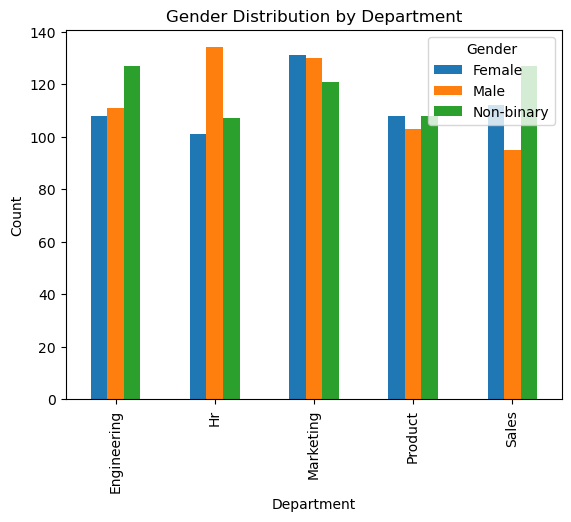

In [74]:
df.groupby("Department")["Gender"].value_counts().unstack().plot(kind="bar")
plt.title("Gender Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

In [75]:
df["Gender"].value_counts()

Gender
Non-binary    590
Male          573
Female        560
Name: count, dtype: int64

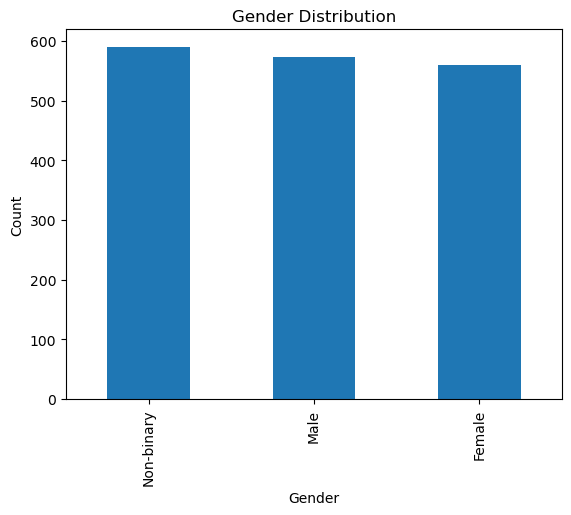

In [76]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [77]:
(df["Gender"].value_counts(normalize=True) * 100).round(2).astype(str) + "%"

Gender
Non-binary    34.24%
Male          33.26%
Female         32.5%
Name: proportion, dtype: object

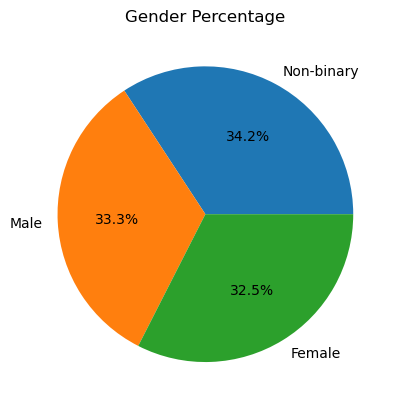

In [78]:
df["Gender"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Gender Percentage")
plt.ylabel("")
plt.show()

In [79]:
(df.groupby("Gender")["Salary"].mean()).round(2)

Gender
Female        108762.50
Male          112897.03
Non-binary    110762.71
Name: Salary, dtype: float64

In [80]:
df["Status"].value_counts()

Status
Active      1165
Resigned     558
Name: count, dtype: int64

In [81]:
((df["Status"].value_counts()["Active"]/len(df))*100).round(2).astype(str)+"%"

'67.61%'

In [82]:
(df.groupby("Department")["Status"].value_counts().round(2))

Department   Status  
Engineering  Active      243
             Resigned    103
Hr           Active      233
             Resigned    109
Marketing    Active      251
             Resigned    131
Product      Active      218
             Resigned    101
Sales        Active      220
             Resigned    114
Name: count, dtype: int64

In [83]:
(df.groupby("Department")["Status"].value_counts(normalize=True).unstack()*100).round(1).astype(str)+"%"


Status,Active,Resigned
Department,,
Engineering,70.2%,29.8%
Hr,68.1%,31.9%
Marketing,65.7%,34.3%
Product,68.3%,31.7%
Sales,65.9%,34.1%


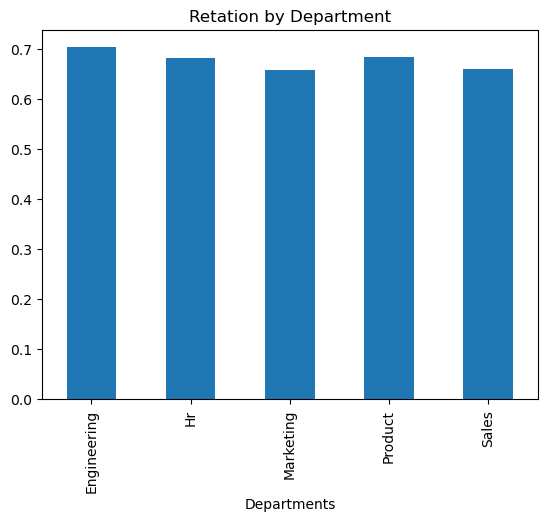

In [84]:
df.groupby("Department")["Status"].value_counts(normalize=True).unstack()["Active"].plot(kind="bar")
plt.title("Retation by Department")
plt.xlabel("Departments")
plt.show()

In [85]:
(df.groupby("Gender")["Status"].value_counts(normalize=True).unstack()*100).round(2).astype(str)+"%"

Status,Active,Resigned
Gender,,
Female,68.57%,31.43%
Male,68.41%,31.59%
Non-binary,65.93%,34.07%


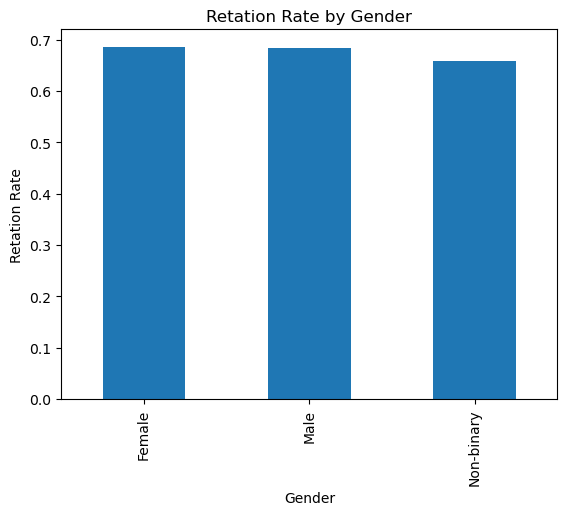

In [86]:
df.groupby("Gender")["Status"].value_counts(normalize=True).unstack()["Active"].plot(kind="bar")
plt.title("Retation Rate by Gender")
plt.ylabel("Retation Rate")
plt.show()

In [87]:
(df.groupby("Department")["Performance_Rating"].mean()).round(2)

Department
Engineering    2.84
Hr             2.91
Marketing      2.93
Product        2.93
Sales          3.01
Name: Performance_Rating, dtype: float64

In [88]:
(df.groupby("Training_Hours")["Status"].value_counts(normalize=True).unstack().round(2))

Status,Active,Resigned
Training_Hours,,
10,0.68,0.32
11,0.68,0.32
12,0.66,0.34
13,0.59,0.41
14,0.72,0.28
15,0.72,0.28
16,0.63,0.37
17,0.70,0.30
18,0.65,0.35


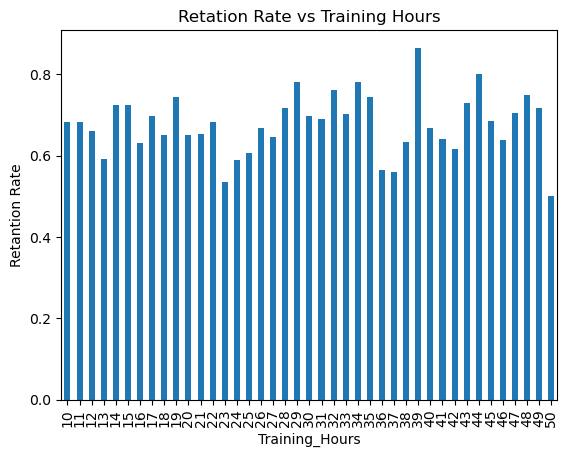

In [89]:
df.groupby("Training_Hours")["Status"].value_counts(normalize=True).unstack()["Active"].plot(kind="bar")
plt.title("Retation Rate vs Training Hours")
plt.ylabel("Retantion Rate")
plt.show()

In [90]:
(df.groupby("Status")[["Training_Hours", "Overtime_Ratio", "Performance_Rating"]].mean()).round(2)

,Training_Hours,Overtime_Ratio,Performance_Rating
Status,,,
Active,29.71,0.26,2.93
Resigned,29.50,0.25,2.89


## Data Cleaning and preprocessing 

The dataset wa cleaned and prepared for machine learning by:
- Handling data columns
- Creating tenure features
- Encoding categorical variables
- Scaling numerical variables
- Handling missing values 

In [91]:
df["Hire_Date"] = pd.to_datetime(df["Hire_Date"])
df["Tenure_Days"]=(pd.Timestamp.today()-df["Hire_Date"]).dt.days

In [92]:
df=df.drop(["Hire_Date","Employee_ID"],axis=1)

In [93]:
df_encoded = pd.get_dummies(df, drop_first=True)
bool_cols=df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols]= df_encoded[bool_cols].astype(int)

In [94]:
X = df_encoded.drop("Status_Resigned", axis=1)
y = df_encoded["Status_Resigned"]

In [95]:
print(X.columns)

Index(['Age', 'Salary', 'Training_Hours', 'Performance_Rating',
       'Overtime_Ratio', 'Tenure_Days', 'Department_Hr',
       'Department_Marketing', 'Department_Product', 'Department_Sales',
       'Gender_Male', 'Gender_Non-binary'],
      dtype='object')


In [96]:
print(X.dtypes.value_counts())

int64      8
float64    4
Name: count, dtype: int64


## Model Training 

A Logistic Regression model was used to classify whether an employee is likely to resign or remain active. 

In [97]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [99]:
import numpy as np
print(np.isnan(X_train).sum())

94


In [100]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X_train =imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [101]:
from sklearn.linear_model import LogisticRegression 
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [102]:
y_pred = model.predict(X_test)

## Model Evaluation 

The model was evaluated using:
- Accuracy score
- Confusion matrix
- Classification Report
- Feature importance analysis

In [103]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)

accuracy: 0.47246376811594204


In [104]:
from sklearn.metrics import confusion_matrix 
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[116 109]
 [ 73  47]]


In [105]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.52      0.56       225
           1       0.30      0.39      0.34       120

    accuracy                           0.47       345
   macro avg       0.46      0.45      0.45       345
weighted avg       0.51      0.47      0.48       345



In [106]:
importance= pd.DataFrame({"Feature":X.columns,"Coefficient":model.coef_[0]})
importance.sort_values(by="Coefficient",ascending=False)

,Feature,Coefficient
1,Salary,0.075679
11,Gender_Non-binary,0.066767
9,Department_Sales,0.060220
7,Department_Marketing,0.056012
2,Training_Hours,0.042840
8,Department_Product,0.034964
5,Tenure_Days,0.010594
6,Department_Hr,-0.009259
4,Overtime_Ratio,-0.014900
0,Age,-0.020011


## Conclusion

The Logistic Regression model achieved moderate performance in predicting employee resignation.

Key findings:
- Salary and department appear to influence resignation risk.
- Class imbalance affected model performance.
- Using balanced class weights improved resignation detection.

Future improvements may include:
- Random Forest models
- Hyperparameter tuning
- Cross-validation
- SMOTE balancing techniques